<a href="https://colab.research.google.com/github/alexatallo/CSI-5810-Project-2/blob/main/CSI5810_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langdetect
from google.colab import files
import pandas as pd
import re
import string
from langdetect import detect

uploaded = files.upload()
df = pd.read_csv("reddit_capitalism_filtered_posts2.csv")

#combine title and body
df['content'] = (df['Title'].fillna('') + ' ' + df['Text'].fillna('')).str.lower()

#clean
def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'u/\w+', '', text)
    text = re.sub(r'[\[\]\*\_>`]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['content'] = df['content'].apply(clean_text)
df['content'] = df['content'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))
df = df.drop_duplicates(subset='content')
df = df[df['content'].str.len() > 20]

#only English posts
def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

df = df[df['content'].apply(is_english)]

df.to_csv("reddit_capitalism_cleaned.csv", index=False)
print("Cleaned dataset saved.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=00e74c597b8c299ea26a50d42c2d11ba6ea218907de9550d49b458b4d9777b46
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


Saving reddit_capitalism_filtered_posts2.csv to reddit_capitalism_filtered_posts2.csv
Cleaned dataset saved.


In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv("reddit_capitalism_cleaned.csv")
analyzer = SentimentIntensityAnalyzer()

#apply VADER to each post
df['vader_scores'] = df['content'].apply(analyzer.polarity_scores)

#extract compound score and categorize sentiment
df['compound'] = df['vader_scores'].apply(lambda x: x['compound'])
df['sentiment'] = df['compound'].apply(lambda c: 'Positive' if c > 0.05
                                       else ('Negative' if c < -0.05 else 'Neutral'))
df[['ID', 'Subreddit', 'compound', 'sentiment', 'content']].head(10)
df.to_csv("reddit_capitalism_sentiment.csv", index=False)
print("Sentiment analysis saved as reddit_capitalism_sentiment.csv")

Sentiment analysis saved as reddit_capitalism_sentiment.csv


In [ ]:
import pandas as pd

import pandas as pd

# Load the original CSV
df_original = pd.read_csv("reddit_capitalism_filtered_posts2.csv")

# Count number of posts per subreddit
subreddit_counts = df_original['Subreddit'].value_counts()

print("Number of posts per subreddit in the original dataset:")
print(subreddit_counts)


#load dataset with sentiment
df = pd.read_csv("reddit_capitalism_sentiment.csv")
df2 = pd.read_csv("reddit_capitalism_cleaned.csv")

print("Total posts:", len(df))
print("Total clean post", len(df2))

#overall sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
print("\nSentiment distribution:")
print(sentiment_counts)

#average compound score
average_compound = df['compound'].mean()
print(f"\nAverage compound score: {average_compound:.3f}")

#subreddit-level sentiment
subreddit_groups = df.groupby('Subreddit')
for subreddit, group in subreddit_groups:
    print(f"\n{subreddit}:")
    print(group['sentiment'].value_counts())
    print("Average compound:", group['compound'].mean())

Number of posts per subreddit in the original dataset:
Subreddit
capitalism              200
capitalismvsocialism    200
socialism                91
Name: count, dtype: int64
Total posts: 491
Total clean post 491

Sentiment distribution:
sentiment
Positive    330
Negative    148
Neutral      13
Name: count, dtype: int64

Average compound score: 0.338

capitalism:
sentiment
Positive    147
Negative     45
Neutral       8
Name: count, dtype: int64
Average compound: 0.45409750000000004

capitalismvsocialism:
sentiment
Positive    137
Negative     60
Neutral       3
Name: count, dtype: int64
Average compound: 0.34592100000000003

socialism:
sentiment
Positive    46
Negative    43
Neutral      2
Name: count, dtype: int64
Average compound: 0.06351978021978022


In [ ]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
df_sentiment = pd.read_csv("reddit_capitalism_sentiment.csv")
df_sentiment["compound"] = df_sentiment["compound"].astype(float)

def long_excerpt(text, length=500):
    if isinstance(text, str):
        return text[:length] + ("..." if len(text) > length else "")
    return ""

#neg post
strong_neg = df_sentiment.loc[df_sentiment["compound"].idxmin()]

#neutral post
neutral_posts = df_sentiment[
    (df_sentiment["compound"] >= -0.05) &
    (df_sentiment["compound"] <= 0.05)
]
neutral_example = neutral_posts.iloc[0] if not neutral_posts.empty else None

#positive post
strong_pos = df_sentiment.loc[df_sentiment["compound"].idxmax()]

table_data = {
    "Sentiment Category": ["Strongly Negative", "Neutral", "Strongly Positive"],
    "Compound Score": [
        round(strong_neg["compound"], 3),
        round(neutral_example["compound"], 3) if neutral_example is not None else None,
        round(strong_pos["compound"], 3),
    ],
    "Example Post": [
        long_excerpt(strong_neg["content"], 500),
        long_excerpt(neutral_example["content"], 500) if neutral_example is not None else "No neutral posts available",
        long_excerpt(strong_pos["content"], 500),
    ],
}

df_examples = pd.DataFrame(table_data)

df_examples

,Sentiment Category,Compound Score,Example Post
0,Strongly Negative,-0.999,the dark history of capitalism capitalisms history begins long before the idea of socialism was conceived and i see so many arguments being made on the point that 20th century socialism was heinous and killed so many people yada yada yada and im going to put this down to recency bias the story of capitalism begins in venice in the 12th or 13th century but not so important for the point im making for that we start in the late 15th century this is where we see the foundation of capitalism begin eu...
1,Neutral,0.028,is piracy a form of anticapitalism i feel like piracy being considered to be a good thing which it isnt it is an act of degeneracy and crime by modern day teens and young adults the most unintelligent of humans when it comes to morals has some kind of anticapitalist or socialist root does anyone agree with me
2,Strongly Positive,1.000,which cultures produce money if iq is held constant and the money is adjusted for cost of living what should you do to maximize your family’s wealth simple copy the best hoarders when comparing occupations or lifestyles grouping by ethnicity can reduce statistical noise members of the same group often share similar values strategies and family approaches—so you can actually see which formula works divide by group copy what works germans are über alles when it comes to hoarding wealth from iq 100...


/tmp/ipython-input-2228909102.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', order=['Positive', 'Neutral', 'Negative'], palette='Set2')


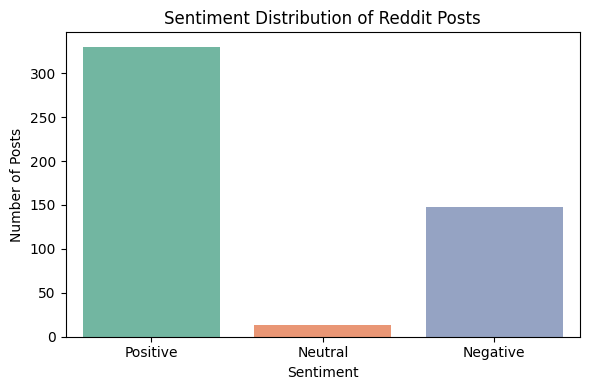

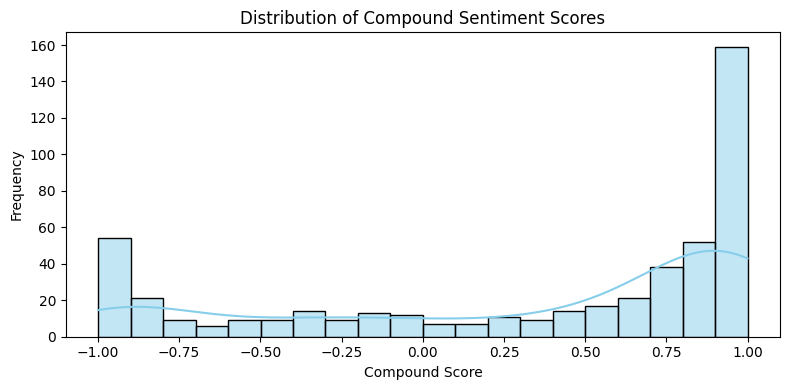

/tmp/ipython-input-2228909102.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_scores, x='Subreddit', y='compound', palette='Set3')


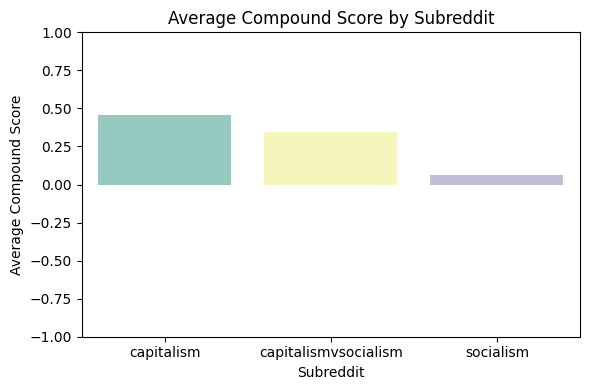

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("reddit_capitalism_sentiment.csv")

df['compound'] = df['compound'].astype(float)

#bar chart
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment', order=['Positive', 'Neutral', 'Negative'], palette='Set2')
plt.title("Sentiment Distribution of Reddit Posts")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

#compound score histogram
plt.figure(figsize=(8,4))
sns.histplot(df['compound'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Compound Sentiment Scores")
plt.xlabel("Compound Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#subreddit comparison chart
avg_scores = df.groupby('Subreddit')['compound'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=avg_scores, x='Subreddit', y='compound', palette='Set3')
plt.title("Average Compound Score by Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Average Compound Score")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()